In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os 

In [2]:
plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 16,
                     'axes.labelsize': 14,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

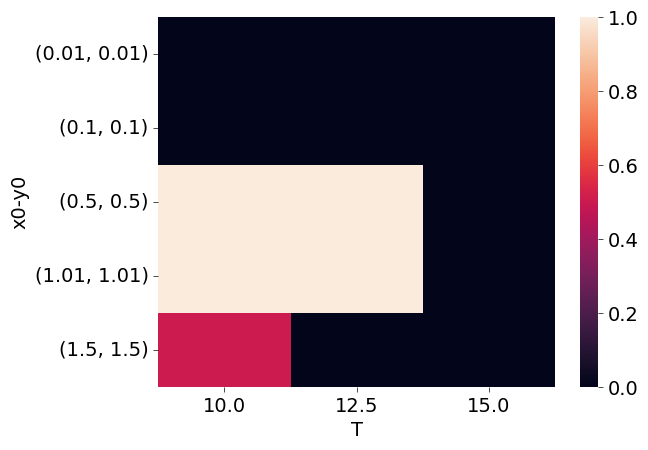

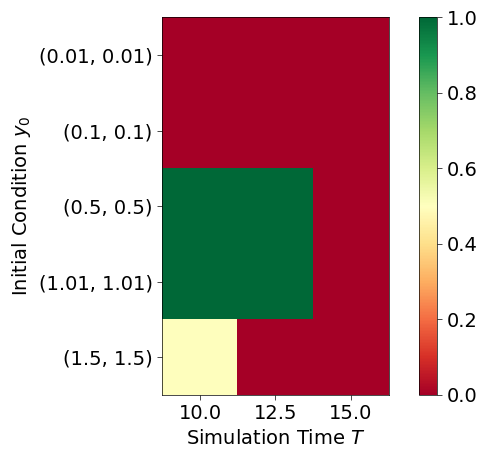

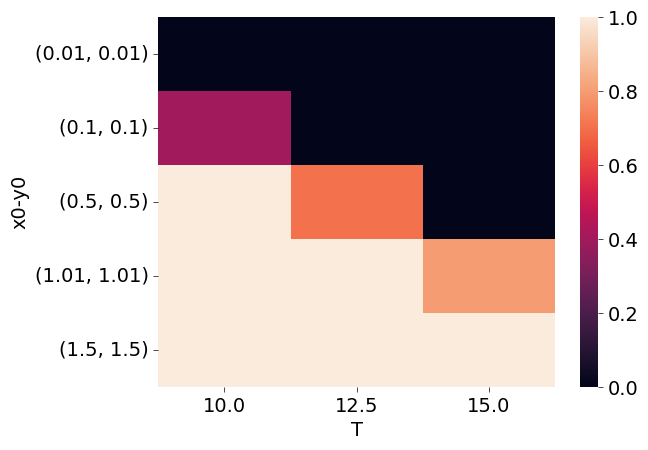

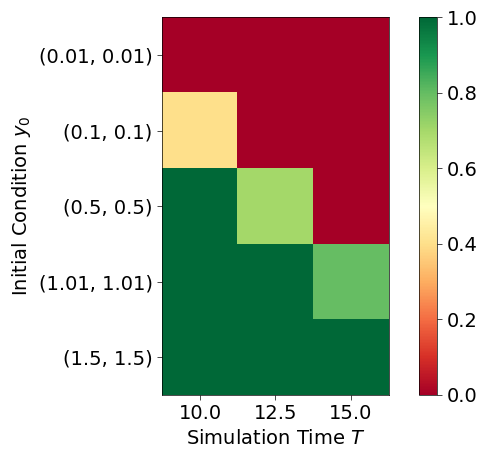

In [7]:
results = pd.read_csv("results_paper/results_reg_additional.csv")

for reg in results["regularization"].unique():
    results_subset = results.loc[results["regularization"] == reg]
    table = pd.pivot_table(results_subset, values="loss_successes_percent", 
                        index=["x0-y0"],
                        columns=["T"],
                        aggfunc="mean")
    
    table.to_csv(f"grid_{reg}_results.csv")
    
    sns.heatmap(table)
    plt.show()

    fig, ax = plt.subplots()

    ims = ax.imshow(table, cmap='RdYlGn')
    fig.colorbar(ims)

    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_xlabel(r'Simulation Time $T$')

    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_ylabel(r'Initial Condition $y_0$')


    plt.tight_layout()
    plt.show()

In [6]:
table_no_reg = pd.read_csv("convergence_points_reg_new.csv")
table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
table_no_reg["x0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[0])
table_no_reg["y0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[1])
table_no_reg["xT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[0])
table_no_reg["yT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}

plt.figure()
sns.scatterplot(data=table_no_reg, x="x0", y="y0", hue="success", style="stability", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

table_reg = pd.read_csv("convergence_points_reg_new.csv")
table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
table_reg["stability with reg"].loc[(table_reg["stability with reg"] == "unstable") & (table_reg["success with reg"] == True)] = "not a fp"
table_reg["x0"] = table_reg["(x0, y0)"].apply(lambda row: eval(row)[0])
table_reg["y0"] = table_reg["(x0, y0)"].apply(lambda row: eval(row)[1])
table_reg["xT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[0])
table_reg["yT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[1])

plt.figure()
sns.scatterplot(data=table_reg, x="x0", y="y0", hue="success with reg", style="stability with reg", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'convergence_points_reg_new.csv'

T-x0-y0 10-(0.1, 0.1),  regularizing distance to fixed point


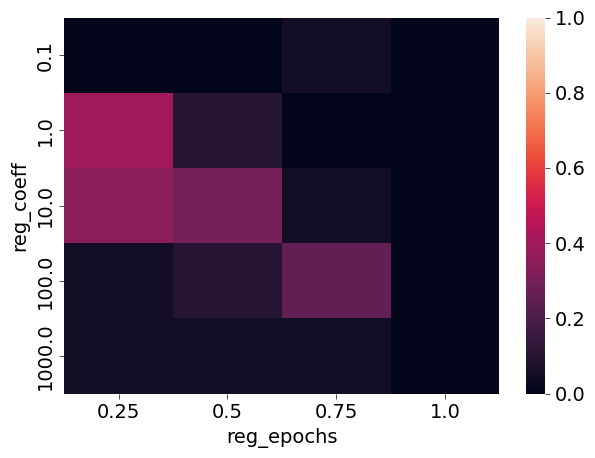

T-x0-y0 10-(0.1, 0.1), regularizing stability around the fixed point


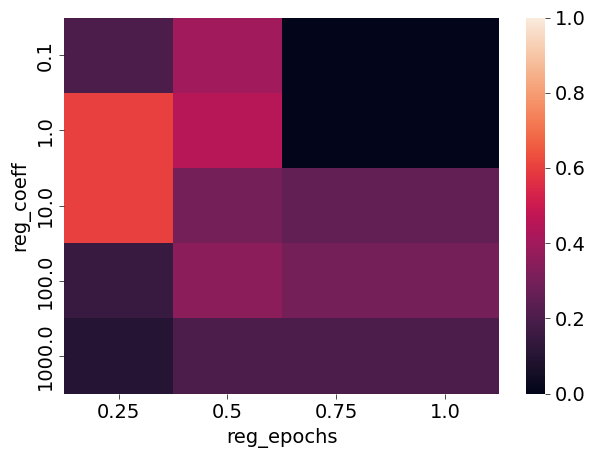

T-x0-y0 10-(0.1, 0.1), regularizing stability


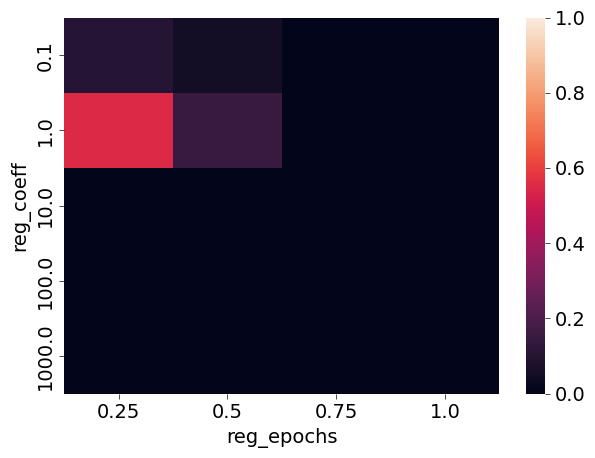

In [11]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}

# results = pd.read_csv("results_linear_decay_new.csv")
results_reg_dist = pd.read_csv("results_reg_derivative_T_10.csv")
results_reg_combo = pd.read_csv("results_reg_combo_T_10.csv")
results_reg_stability = pd.read_csv("results_reg_stability_T_10.csv")
results = pd.concat([results_reg_dist, results_reg_combo, results_reg_stability])

dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)

results["T-x0-y0"] = results["T"].astype(str) + "-" + results["x0-y0"].astype(str) 

for settings in results["T-x0-y0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-x0-y0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")

        table.to_csv(f"{dirname}/2d_toy_example_results_{regularization}_settingsT-y0_{settings}.csv")


        sns.heatmap(table, vmin=0, vmax=1)
        # plt.title(f"T-x0-y0 {settings}, {regularization_names[regularization]}")
        print(f"T-x0-y0 {settings}, {regularization_names[regularization]}")
        plt.tight_layout()
        plt.savefig(f"{dirname}/2d_toy_example_results_{regularization}_settingsT-y0_{settings}.png")
        plt.show()
        